# Tarea 4. Muestreo de distribuciones

<img style="float: right; margin: 0px 0px 15px 15px;" src="https://storage.needpix.com/rsynced_images/bayesian-2889576_1280.png" width="200px" height="180px" />

En esta cuarta tarea, reforzaremos el muestreo de distribuciones usando los métodos vistos en clase.

Recuerda que ante cualquier duda, me puedes contactar al correo esjimenezro@iteso.mx.

<p style="text-align:right;"> Imagen recuperada de: https://storage.needpix.com/rsynced_images/bayesian-2889576_1280.png.</p>

In [106]:
from matplotlib import pyplot as plt
from scipy.stats import lognorm, norm, bernoulli
from scipy.integrate import quad
import numpy as np

Considere la distribución de probabilidad no normalizada definida a través de la siguiente función de python:

In [107]:
def rare_pdf(x):
    return lognorm.pdf(x, loc=0, s=0.5) + lognorm.pdf(x, loc=2, s=0.3)

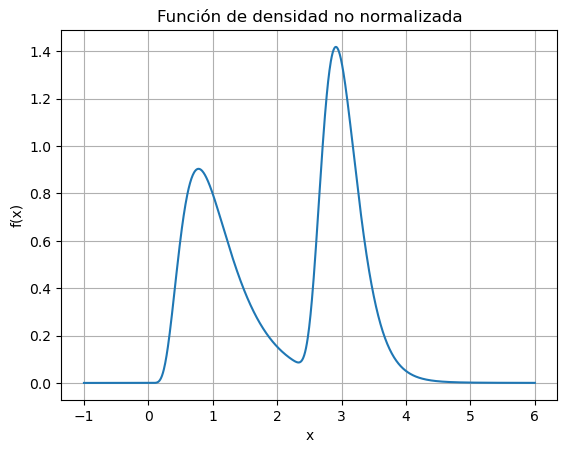

In [108]:
x = np.linspace(-1, 6, 1000)
plt.plot(x, rare_pdf(x))
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Función de densidad no normalizada')
plt.grid()

Para muestrear de esta distribución, vamos a comparar dos algoritmos de muestreo y rechazo que vimos. Implementar:

1. (40 puntos) El algoritmo de muestreo y rechazo para distribuciones univariadas. Recuerde que acá debes elegir un múltiplo escalar de una distribución normal $K \mathcal{N(x|\mu, \sigma)}$ que acote por arriba la distribución que debemos muestrear. Debe de elegir $K$ lo más justo posible para que el algoritmo no "desperdice" muchas muestras. También debe elegir $\mu$ y $\sigma$ cuidadosamente.

2. (40 puntos) El algortimo de Metrópolis-Hastings, eligiendo como distribución de muestreo $Q(x -> x') = \mathcal{N}(x'|x, \sigma^*) = \mathcal{N}(x|x', \sigma^*) = Q(x' -> x)$. Acá, debe de elegir $\sigma^*$. Un buen punto de arranque es el $\sigma$ que eligió en el punto anterior. Recuerde que una vez definida $Q$, debe construir la distribución de aceptación $A$ para el algoritmo.

En ambos casos **provea los histogramas de las muestras** contrastándolos con le función de densidad **normalizada** (para encontrarla puedes dividir la densidad no normalizada por el valor de la integral de la misma desde $-\infty$ hasta $\infty$ - puedes usar el métodos scipy.integrate.quad para hacer el cálculo numérico de la integral), para ver que todo esté funcionando correctamente.

Al generar 10000 muestras con ambos esquemas:

* (10 puntos) ¿Cuál algoritmo resultó ser más eficiente respecto a la proporción de muestras aceptadas?
* (10 puntos) ¿Por qué cree que sucedió esto?

### Algoritmo muestreo y rechazo

In [109]:
k = 6
X = norm(loc=2.25, scale=1.5)

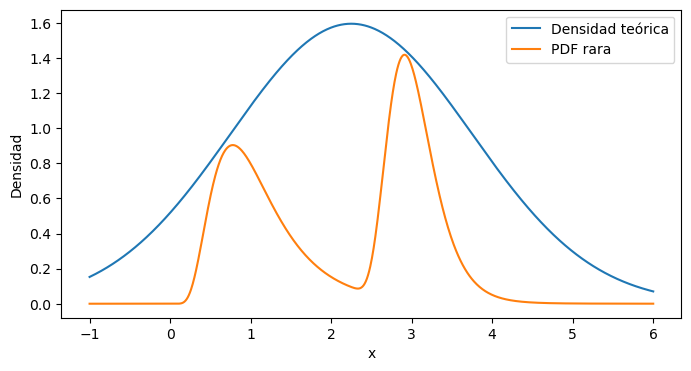

In [110]:
# Gráficamente
x_ = np.linspace(-1, 6, 1001)
pdf = X.pdf(x_)
plt.figure(figsize=(8, 4))
plt.plot(x_, k * pdf, label="Densidad teórica")
plt.plot(x_, rare_pdf(x_), label="PDF rara")
plt.xlabel("x")
plt.ylabel("Densidad")
plt.legend()
plt.show()

In [111]:
# Número de muestras
n_samples = 10000
# Generamos x_tilde de la normal
x_tilde = X.rvs(size=n_samples)
# Muestreamos y
y = np.random.uniform(low=0, high=k * X.pdf(x_tilde))
# Corregimos muestras
x_tilde_corr = x_tilde[y < rare_pdf(x_tilde)]

In [112]:
x_tilde_corr.shape

(3303,)

In [113]:
# Hallamos integral de función no normalizada
integral, error = quad(rare_pdf, -np.inf, np.inf)
integral, error

(2.000000000000352, 1.5578795218712967e-08)

In [114]:
# Densidad normalizada
def normalized_pdf(x):
    return rare_pdf(x) / integral

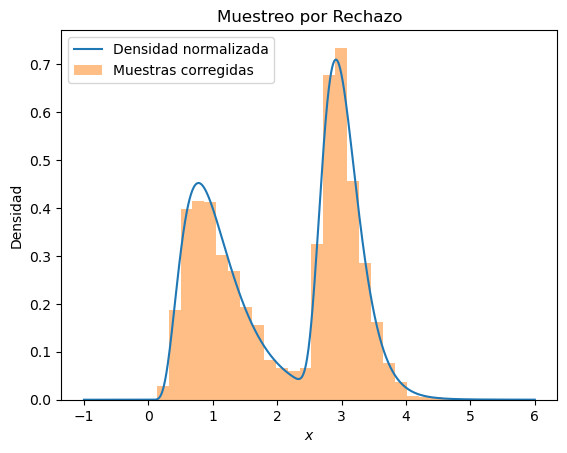

In [125]:
# Gráfico vs. DISTRIBUCIÓN NORMALIZADA
plt.plot(x_, normalized_pdf(x_), label="Densidad normalizada")
plt.hist(x_tilde_corr, bins=30, density=True, alpha=0.5, label="Muestras corregidas")
plt.title("Muestreo por Rechazo")
plt.xlabel("$x$")
plt.ylabel("Densidad")
plt.legend()
plt.show()

In [104]:
print(f"Número de muestras aceptadas: {len(x_tilde_corr)}")
print(f"Tasa de aceptación: {len(x_tilde_corr)/n_samples}")

Número de muestras aceptadas: 3337
Tasa de aceptación: 0.3337


### Algortimo Metrópolis-Hastings

In [133]:
def metropolis_hastings(x0, M, sigma_propuesta=1.0):

    xs = np.zeros(M + 1)
    xs[0] = x0

    n_accept = 0
    
    for k in range(M):
        xk = xs[k]
        
        xk1 = norm.rvs(loc=xk, scale=sigma_propuesta)

        A = min(1, rare_pdf(xk1) / rare_pdf(xk))

        u = np.random.uniform(0, 1)
        if u <= A:
            xs[k + 1] = xk1
            n_accept += 1
        else:
            xs[k + 1] = xk
            
    tasa_aceptacion = n_accept / M
    
    return xs, tasa_aceptacion

In [149]:
mh_samples, tasa = metropolis_hastings(x0=1, M=10_000, sigma_propuesta=0.4)

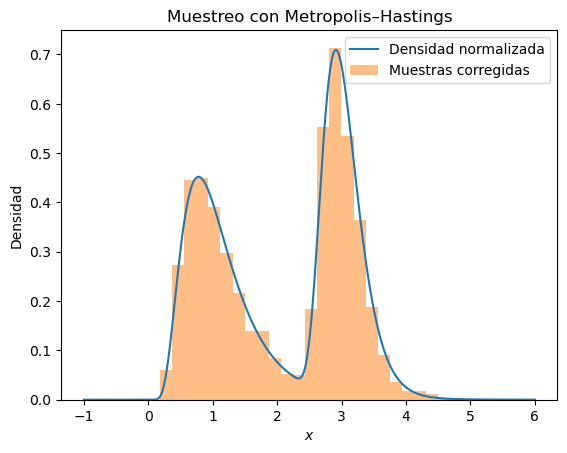

In [150]:
# Gráfico vs. DISTRIBUCIÓN NORMALIZADA
plt.plot(x_, normalized_pdf(x_), label="Densidad normalizada")
plt.hist(mh_samples, bins=30, density=True, alpha=0.5, label="Muestras corregidas")
plt.title("Muestreo con Metropolis–Hastings")
plt.xlabel("$x$")
plt.ylabel("Densidad")
plt.legend()
plt.show()

In [151]:
print(f"Número de muestras aceptadas: {10000*tasa}")
print(f"Tasa de aceptación: {tasa}")

Número de muestras aceptadas: 6895.0
Tasa de aceptación: 0.6895


- ¿Cuál algoritmo resultó ser más eficiente respecto a la proporción de muestras aceptadas?
    
    El algoritmo que resulto ser mas eficiente fue el de Metropolis-Hastings con una tasa de aceptación de 0.6895 contra el algoritmo de muestreo y rechazo que tuvo una tasa de aceptación de 0.3337


- ¿Por qué cree que sucedió esto?

    Por como funcionan los algoritmos de muestreo. Mientras que el de muestreo y rechazo dependes de las cota para aceptar o rechazar, y siempre las zonas con baja densidad van a ser dificil de aceptar. Lo que genera muchos rechazos. En cambio lo que hace MH es como caminar sobre la distribución y en zonas de densidad altas simpre o casi siempre lo va a acpetar, y en zonas de densidad baja aveces. Tambien se podria decir que el metodo de MH acepta mas porque exploxara la distribucion.
    

<script>
  $(document).ready(function(){
    $('div.prompt').hide();
    $('div.back-to-top').hide();
    $('nav#menubar').hide();
    $('.breadcrumb').hide();
    $('.hidden-print').hide();
  });
</script>

<footer id="attribution" style="float:right; color:#808080; background:#fff;">
Created with Jupyter by Esteban Jiménez Rodríguez.
</footer>